Index(['ID', 'Gender', 'Age', 'Customer Type', 'Type of Travel', 'Class',
       'Flight Distance', 'Departure Delay', 'Arrival Delay',
       'Departure and Arrival Time Convenience', 'Ease of Online Booking',
       'Check-in Service', 'Online Boarding', 'Gate Location',
       'On-board Service', 'Seat Comfort', 'Leg Room Service', 'Cleanliness',
       'Food and Drink', 'In-flight Service', 'In-flight Wifi Service',
       'In-flight Entertainment', 'Baggage Handling', 'Satisfaction'],
      dtype='object')
The mean of 'Flight Distance' is: 1190.316
The median of 'Flight Distance' is: 844.0
The variance of 'Flight Distance' is: 994911.4445252272
The standard deviation of 'Flight Distance' is: 997.4524773267282
The standard error of 'Flight Distance' is: 2.7677131254724423
The skewness of 'Flight Distance' is: 1.108
First Quartile (Q1): 414.0
Third Quartile (Q3): 1744.0
Interquartile Range (IQR): 1330.0
Lower Bound for Outliers: -1581.0
Upper Bound for Outliers: 3739.0

Outliers in 

,ID,Flight Distance
5,6,3788
58,59,3997
148,149,3758
173,174,3822
185,186,3880


Total number of outliers: 2855


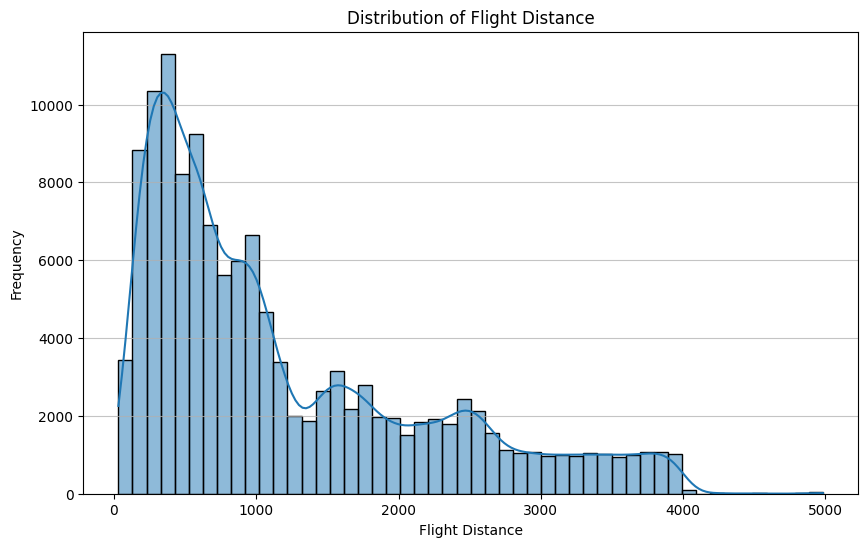

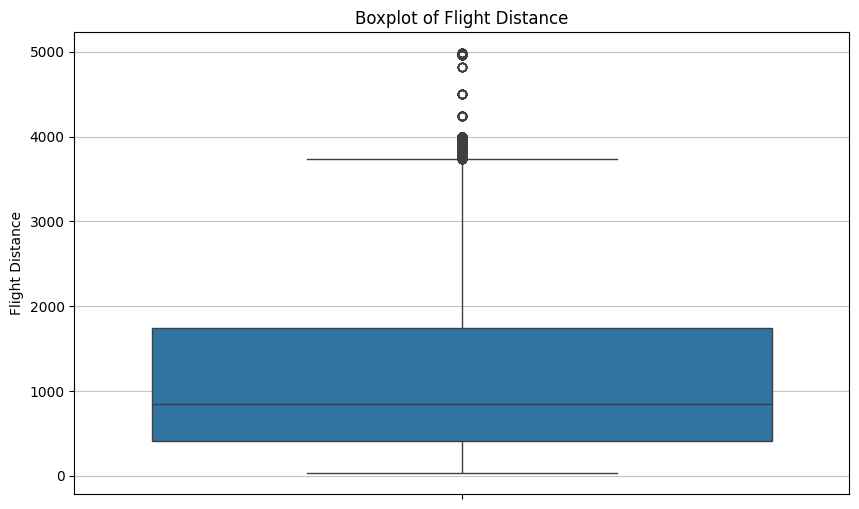

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

airline = pd.read_excel("/content/airline_passenger_satisfaction.xlsx")

print(airline.columns)
airline.head()

# 1. Mean of Column Data.
mean_flight_distance = airline['Flight Distance'].mean().round(3)
print(f"The mean of 'Flight Distance' is: {mean_flight_distance}")

# 2. Median of Column Data.
median_flight_distance = airline['Flight Distance'].median()
print(f"The median of 'Flight Distance' is: {median_flight_distance}")

# 3. Variance, Standard Deviation and Standard Error.
variance_flight_distance = airline['Flight Distance'].var()
std_dev_flight_distance = airline['Flight Distance'].std()
std_err_flight_distance = airline['Flight Distance'].sem()

print(f"The variance of 'Flight Distance' is: {variance_flight_distance}")
print(f"The standard deviation of 'Flight Distance' is: {std_dev_flight_distance}")
print(f"The standard error of 'Flight Distance' is: {std_err_flight_distance}")

# 4. Decide the Shape of Distribution.
skewness_flight_distance = airline['Flight Distance'].skew().round(3)
print(f"The skewness of 'Flight Distance' is: {skewness_flight_distance}")

# 5. Find Outliers.
Q1 = airline['Flight Distance'].quantile(0.25)
Q3 = airline['Flight Distance'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = airline[(airline['Flight Distance'] < lower_bound) | (airline['Flight Distance'] > upper_bound)]

print(f"First Quartile (Q1): {Q1}")
print(f"Third Quartile (Q3): {Q3}")
print(f"Interquartile Range (IQR): {IQR}")
print(f"Lower Bound for Outliers: {lower_bound}")
print(f"Upper Bound for Outliers: {upper_bound}")

if not outliers.empty:
    print("\nOutliers in 'Flight Distance' column:")
    display(outliers[['ID', 'Flight Distance']].head())
    print(f"Total number of outliers: {len(outliers)}")
else:
    print("\nNo outliers detected in 'Flight Distance' column using the IQR method.")

# 6. Graph the Column Data and Comment.
plt.figure(figsize=(10, 6))
sb.histplot(airline['Flight Distance'], bins=50, kde=True)
plt.title('Distribution of Flight Distance')
plt.xlabel('Flight Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# Comment on the 'Flight Distance' Distribution:

# From the histogram, we can observe the following characteristics of the 'Flight Distance' distribution:

# Shape:            The distribution is clearly right-skewed, which aligns with our calculated positive skewness of approximately 1.108.
#                   This means there is a long tail extending to the right, indicating a higher frequency of shorter flights and fewer very long flights.

# Central Tendency: The peak of the distribution is towards the lower 'Flight Distance' values, indicating that most flights are relatively short.
#                   The median (844.0) is less than the mean (1190.32), which is typical for a right-skewed distribution.

# Spread:           The data is quite spread out, as indicated by the standard deviation (997.45).
#                   This suggests a wide range of flight distances.

# Outliers:         The long tail on the right side of the histogram visually confirms the presence of many high-value outliers that we identified (2855 outliers).
#                   These are the longer flights that extend far beyond the typical flight distances.

# 7. Boxplot.
plt.figure(figsize=(10, 6))
sb.boxplot(y=airline['Flight Distance'])
plt.title('Boxplot of Flight Distance')
plt.ylabel('Flight Distance')
plt.grid(axis='y', alpha=0.75)
plt.show()
